# **EDA Notebook**
IDX Exchange Weeks 2-3 Assignment 

by Jack Phelan : )

In [1]:
#importd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from idx.utils import get_histogram, get_boxplot, get_missing_report
from idx.config import RAW_LISTINGS_DIR, RAW_SOLD_DIR
from pathlib import Path

In [2]:
# loading data from concat-ed csv
listings_df_raw = pd.read_csv(Path("..") / RAW_LISTINGS_DIR, low_memory=False)
sold_df_raw = pd.read_csv(Path("..") / RAW_SOLD_DIR, low_memory=False)

In [3]:
# previews
listings_df_raw.head(5)

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.0,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.0,Huntington Beach Union High,92649,NaN,330.0,1847.0,NaN,16882 Canyon Lane,NaN,NaN
1,999999.0,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.0,Inglewood Unified,90305,NaN,0.0,8508.0,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.0,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.858559,-116.542169,505 E Molino Road,...,2.0,Palm Springs Unified,92262,NaN,NaN,10890.0,NaN,505 E Molino Road,NaN,NaN
3,4998888.0,1076193812,ernieramos62@yahoo.com,NaN,NaN,Ernesto,Ramos,NaN,NaN,3653 Halldale Avenue,...,0.0,NaN,90018,NaN,NaN,6192.0,NaN,3653 Halldale Avenue,NaN,NaN
4,549000.0,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.0,Los Angeles Unified,90221,NaN,0.0,4113.0,NaN,1736 N Mcdivitt Avenue,NaN,NaN


In [4]:
sold_df_raw.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,True,NaN,NaN,NaN,159000.0,555125771,deborah.potestio@c21selectgroup.com,2024-04-29,45000.0,...,95916,0.0,336283.2,NaN,False,False,NaN,NaN,NaN,NaN
1,NaN,True,NaN,NaN,NaN,144000.0,554271746,crchapman@sbcglobal.net,2024-04-26,78000.0,...,95966,0.0,101495.0,NaN,False,False,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,265000.0,543251400,michaelg@londonproperties.com,2024-04-02,250000.0,...,93726,0.0,8100.0,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,925000.0,539236677,chris.campbell@msn.com,2024-04-10,815000.0,...,92223,0.0,564988.0,NaN,False,False,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,25000.0,538449222,rrinder@sbcglobal.net,2024-04-06,15000.0,...,95966,0.0,6098.0,NaN,False,False,NaN,NaN,NaN,NaN


# **Listings Analysis**

## **Dataset Overview**

In [5]:
# basic info about data
print("Listings DataFrame Info:")
print(listings_df_raw.shape[0], "rows,", listings_df_raw.shape[1], "columns")
print("Number of float columns:", len(listings_df_raw.select_dtypes(include=['float64']).columns.tolist()))
print("Number of int columns:", len(listings_df_raw.select_dtypes(include=['int64']).columns.tolist()))
print("Number of object columns:", len(listings_df_raw.select_dtypes(include=['object']).columns.tolist()))
print("Number of string columns:", len(listings_df_raw.select_dtypes(include=['string']).columns.tolist()))

Listings DataFrame Info:
893594 rows, 84 columns
Number of float columns: 32
Number of int columns: 4
Number of object columns: 48
Number of string columns: 0


In [6]:
# specific dtypes 
display(listings_df_raw.dtypes)

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
BuyerAgencyCompensationType      object
BuyerAgencyCompensation         float64
Length: 84, dtype: object

In [7]:
listings_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893594 entries, 0 to 893593
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             890150 non-null  float64
 1   ListingKey                    893594 non-null  int64  
 2   ListAgentEmail                891222 non-null  object 
 3   CloseDate                     257985 non-null  object 
 4   ClosePrice                    233372 non-null  float64
 5   ListAgentFirstName            888314 non-null  object 
 6   ListAgentLastName             893511 non-null  object 
 7   Latitude                      781122 non-null  float64
 8   Longitude                     781848 non-null  float64
 9   UnparsedAddress               891239 non-null  object 
 10  PropertyType                  893594 non-null  object 
 11  LivingArea                    782759 non-null  float64
 12  ListPrice                     891376 non-nul

In [8]:
listings_df_raw.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.0,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.0,Huntington Beach Union High,92649,NaN,330.0,1847.0,NaN,16882 Canyon Lane,NaN,NaN
1,999999.0,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.0,Inglewood Unified,90305,NaN,0.0,8508.0,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.0,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.858559,-116.542169,505 E Molino Road,...,2.0,Palm Springs Unified,92262,NaN,NaN,10890.0,NaN,505 E Molino Road,NaN,NaN
3,4998888.0,1076193812,ernieramos62@yahoo.com,NaN,NaN,Ernesto,Ramos,NaN,NaN,3653 Halldale Avenue,...,0.0,NaN,90018,NaN,NaN,6192.0,NaN,3653 Halldale Avenue,NaN,NaN
4,549000.0,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.0,Los Angeles Unified,90221,NaN,0.0,4113.0,NaN,1736 N Mcdivitt Avenue,NaN,NaN


In [9]:
METADATA_COLS = ['ListingKey', 'BuyerAgentMlsId', 'ListingKeyNumeric', 'MlsStatus', 'ListingId']

# check datatypes



Notes on datatypes 
- date cols are not actually datetime (but mostly empty anyway so not super important / just ask about it at meeting)
- 

## **Missingness Assessment**

In [10]:
listings_missing_report = get_missing_report(listings_df_raw, flag_high_missing=True, threshold=0.9, index_col='column')

display(listings_missing_report)

,missing_count,pct_missing,high_missing
column,,,
FireplacesTotal,893594,100.0,True
ElementarySchoolDistrict,893594,100.0,True
MiddleOrJuniorSchoolDistrict,893594,100.0,True
CoveredSpaces,893594,100.0,True
AboveGradeFinishedArea,893594,100.0,True
...,...,...,...
MlsStatus,0,0.0,False
ListingKey,0,0.0,False
ListingId,0,0.0,False


In [11]:
# collecting cols to drop

COLS_TO_DROP = listings_missing_report[listings_missing_report['high_missing']].index.tolist() # 90% Missing or more

# all high missing and can maybe be acquired from zip code data separatley
SCHOOL_COLS = ['ElementarySchool', 'HighSchool', 'MiddleOrJuniorSchool'] 

# lots of columns that are only filled on listings that were sold - ask about if they should be kept or not

# lots of name columns that could be useless or semi useless its tbd

## **Numeric Distribution Analysis**

Analyze the distribution of key numeric fields: 
- ClosePrice, 
- ListPrice, 
- OriginalListPrice, 
- LivingArea,
- LotSizeAcres, 
- BedroomsTotal, 
- BathroomsTotalInteger, 
- DaysOnMarket, 
- YearBuilt. 




For each field:
-  generate histograms,
-  boxplots,
-  percentile summaries,
-  identify extreme outliers for later handling.

In [12]:

NUMERIC_FIELDS_TO_ANALYZE = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "DaysOnMarket",
    "YearBuilt"
]

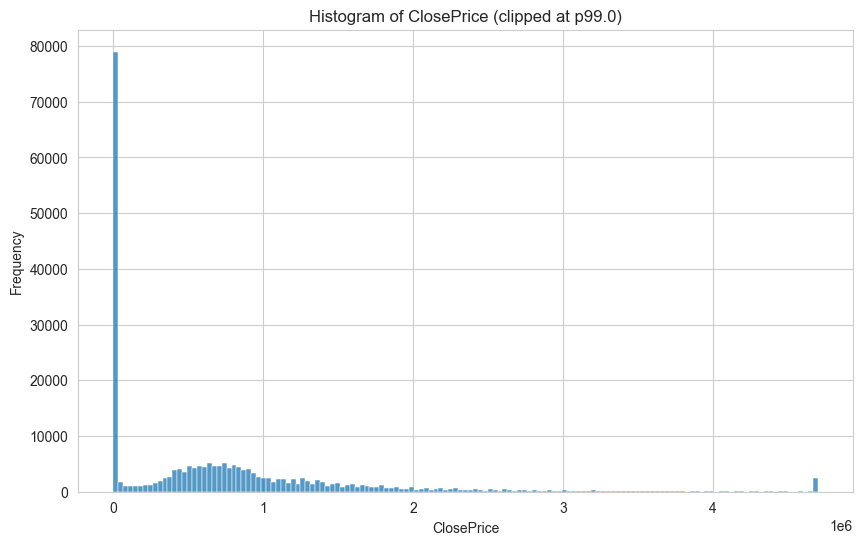

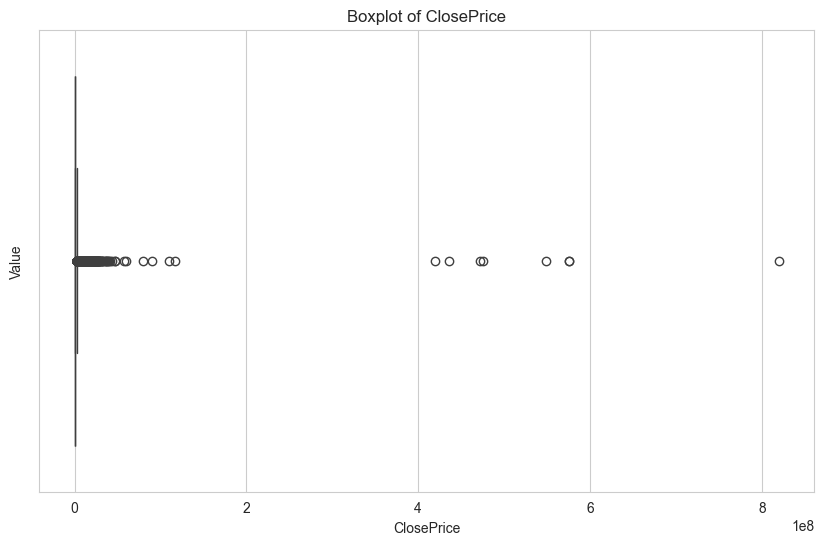

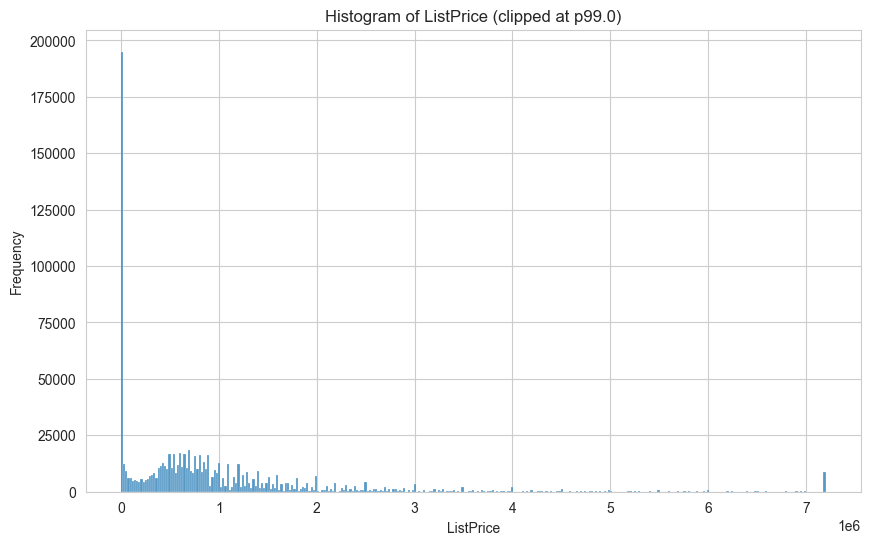

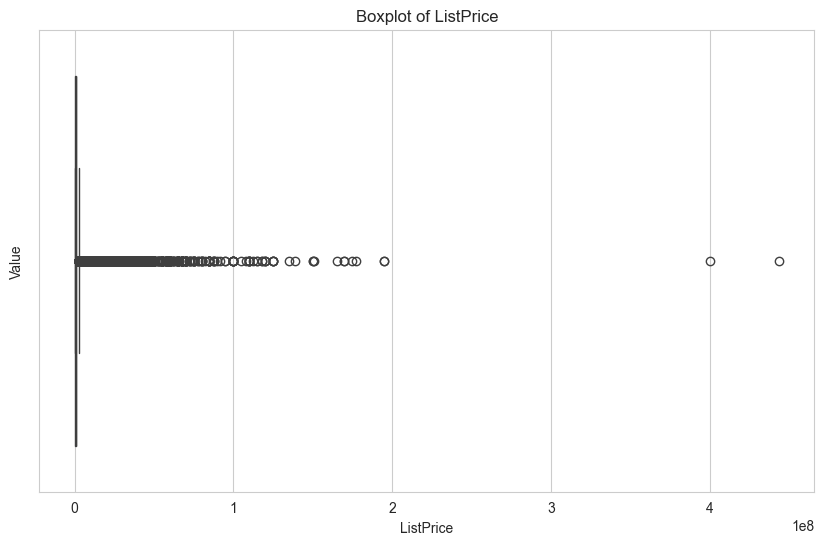

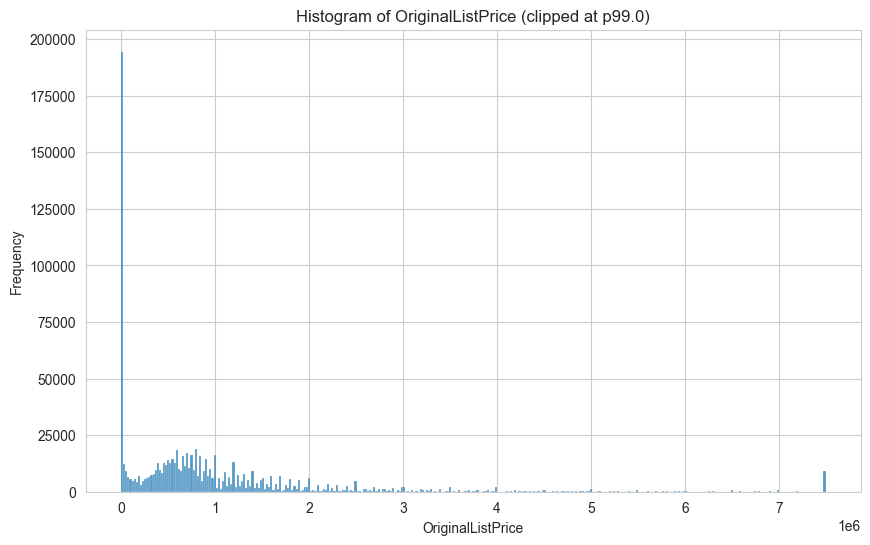

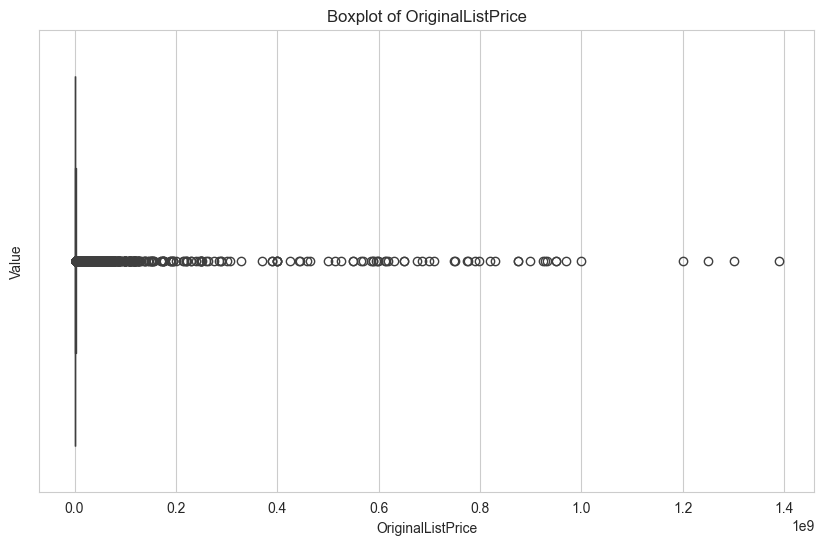

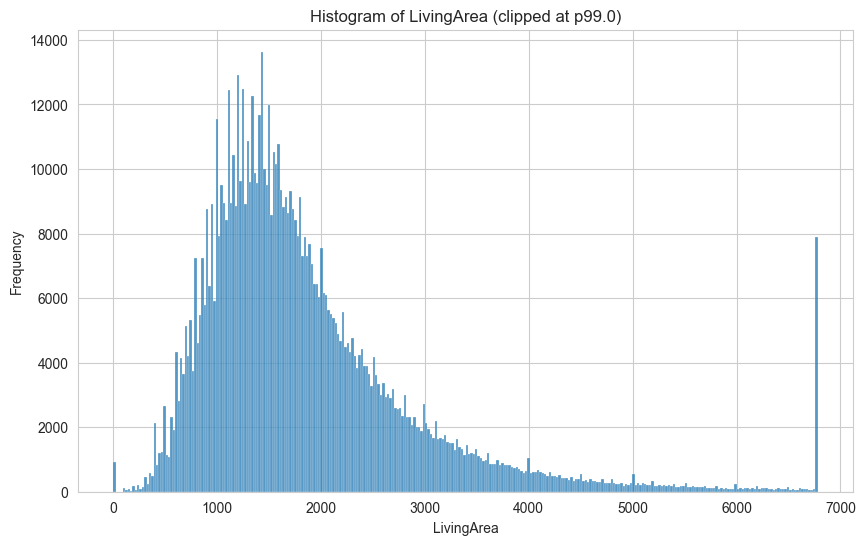

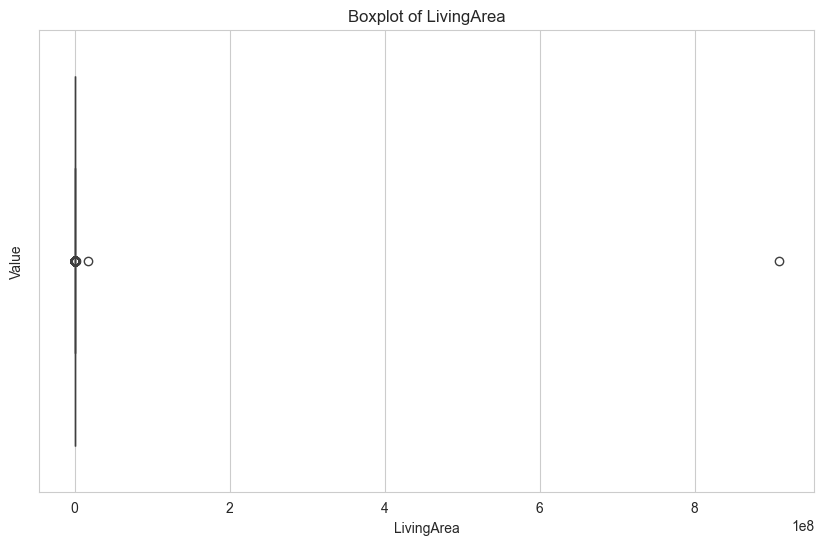

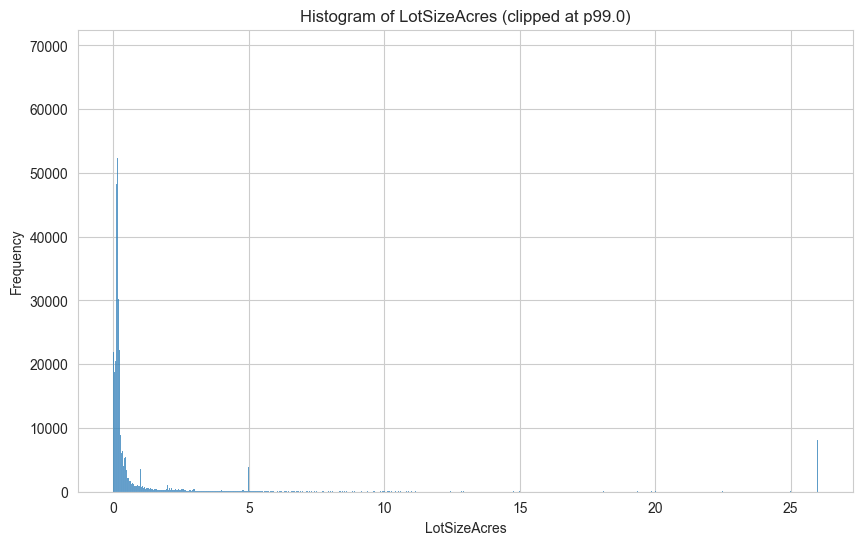

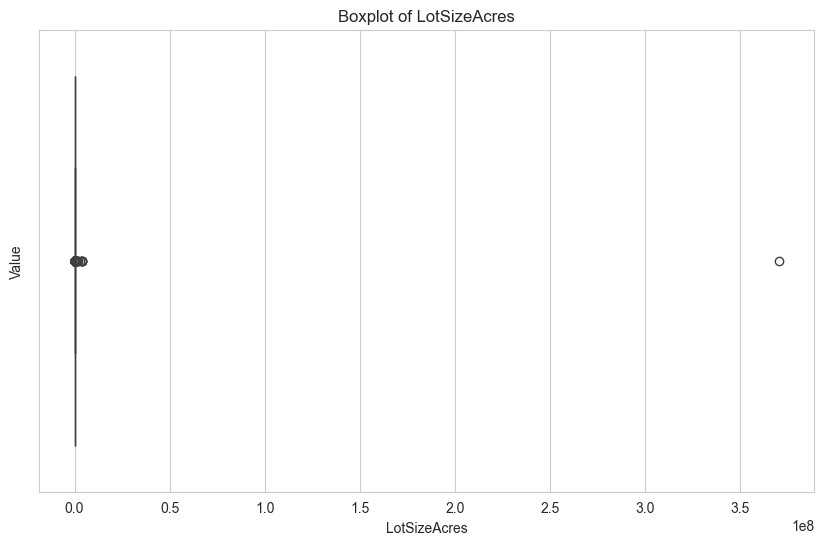

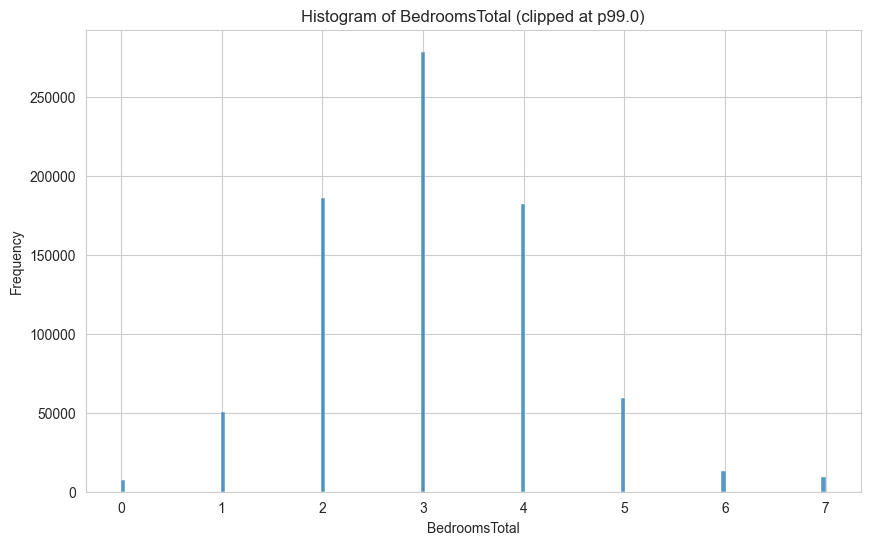

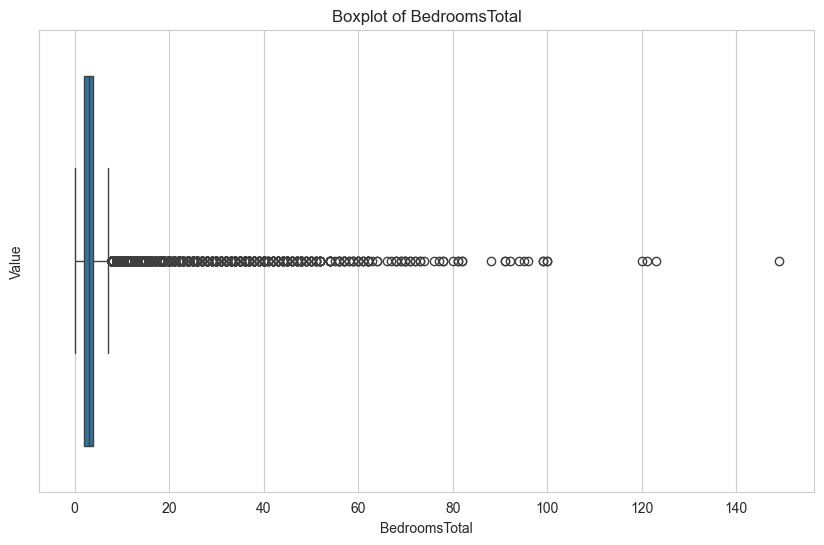

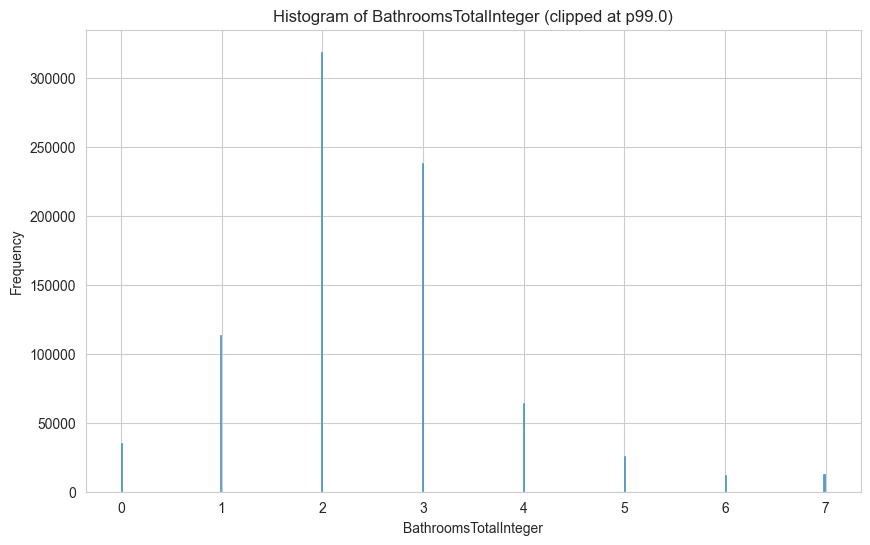

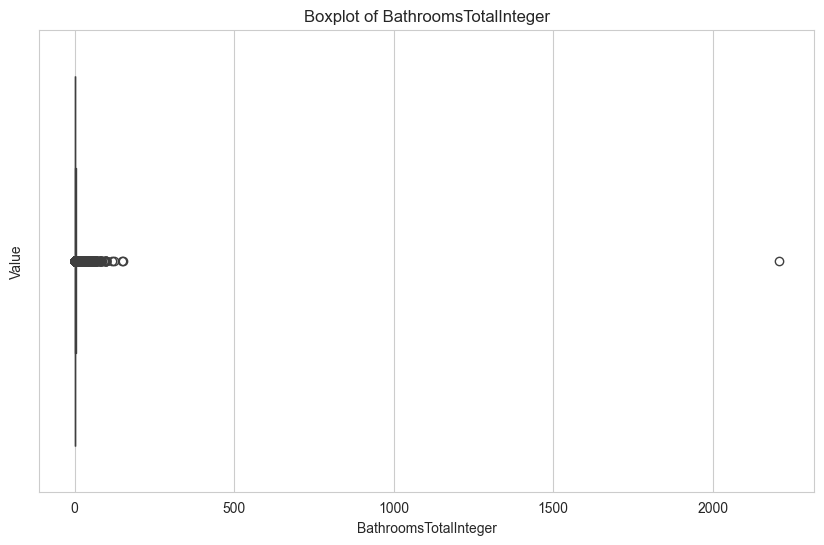

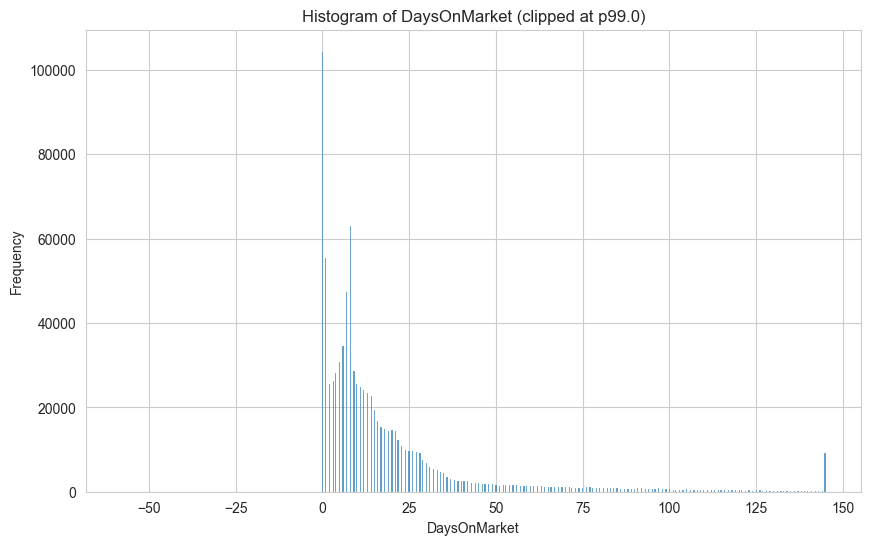

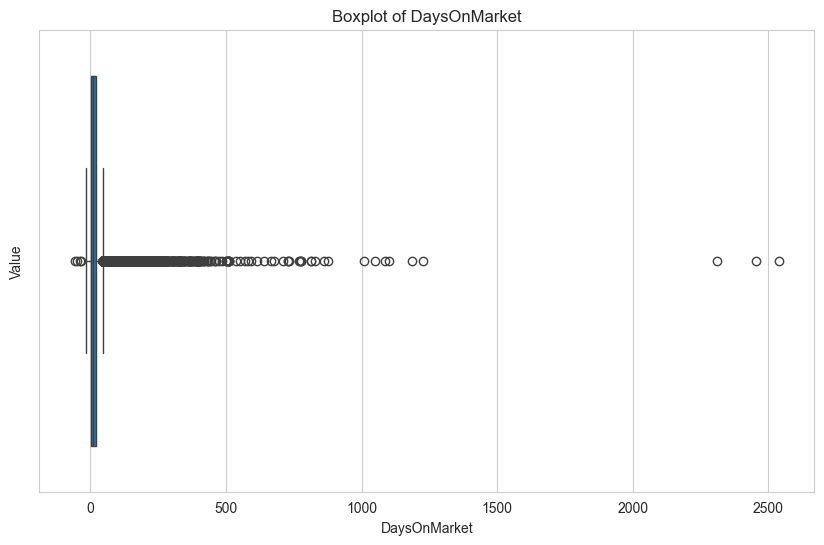

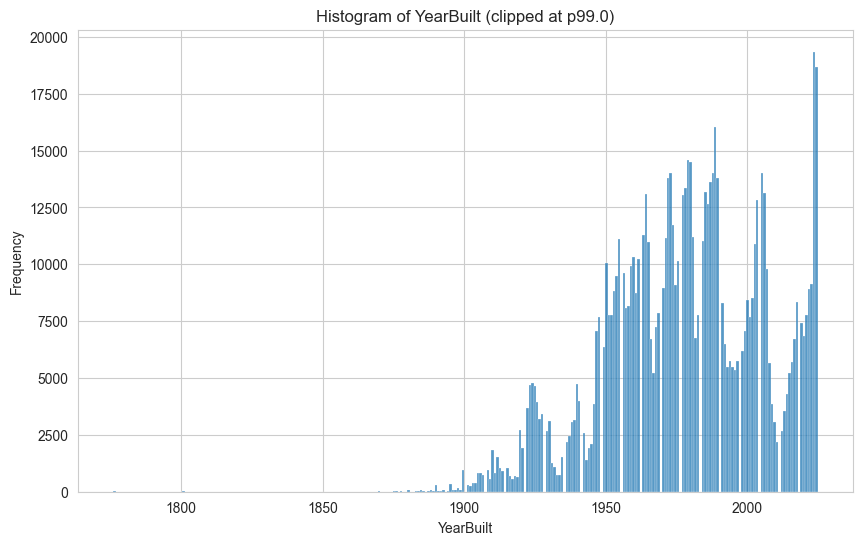

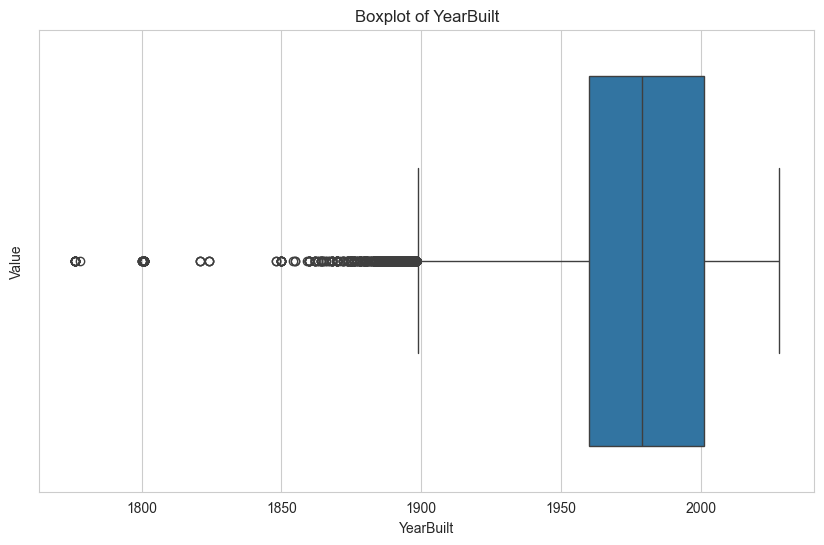

In [13]:
for col in NUMERIC_FIELDS_TO_ANALYZE:
    get_histogram(listings_df_raw, col, bins="auto", title=f"Histogram of {col}", clip_quantile=0.99)
    get_boxplot(listings_df_raw, col, title=f"Boxplot of {col}")

In [14]:
DISTR_COLS = [ "ClosePrice", "LivingArea", "DaysOnMarket"]

listings_df_raw[DISTR_COLS].describe()

,ClosePrice,LivingArea,DaysOnMarket
count,2.333720e+05,7.827590e+05,893594.000000
mean,7.789454e+05,3.104491e+03,18.571821
std,3.457924e+06,1.027712e+06,28.357769
min,0.000000e+00,0.000000e+00,-58.000000
25%,4.995000e+03,1.183000e+03,4.000000
50%,5.600000e+05,1.603000e+03,10.000000
75%,1.020000e+06,2.239000e+03,21.000000
max,8.200000e+08,9.090909e+08,2539.000000


## **Outlier Detection**

In [15]:
import numpy as np
import scipy.stats as stats

iqrs = listings_df_raw[DISTR_COLS].apply(lambda x: stats.iqr(x, nan_policy='omit'))

lower_bounds = listings_df_raw[DISTR_COLS].apply(lambda x: np.percentile(x, 25) - 1.5 * stats.iqr(x, nan_policy='omit'))
upper_bounds = listings_df_raw[DISTR_COLS].apply(lambda x: np.percentile(x, 75) + 1.5 * stats.iqr(x, nan_policy='omit'))

In [16]:
outliers = {}
for col in DISTR_COLS:
    outliers[col] = listings_df_raw[(listings_df_raw[col] < lower_bounds[col]) | (listings_df_raw[col] > upper_bounds[col])]


outliers_counts = {col: len(outliers[col]) for col in DISTR_COLS}

outliers_counts_df = pd.DataFrame.from_dict(outliers_counts, orient='index', columns=['Outlier Count'])

outliers_counts_df # ALOT OF OUTLIERS


,Outlier Count
ClosePrice,0
LivingArea,0
DaysOnMarket,80890


In [17]:
from idx.utils import get_iqr_outliers

outliers_test = get_iqr_outliers(listings_df_raw, DISTR_COLS)

Outlier Counts
----------------------------------------
ClosePrice: 10400 outliers
LivingArea: 42029 outliers
DaysOnMarket: 80890 outliers


DaysOnMarket has 10,4266 zeroes, as well as 36 negatives. Will have to ask about data specifically

In [18]:
"""from data_profiling import ProfileReport
from IPython.display import display
    
profile = ProfileReport(listings_df_raw, title="Profiling Report", explorative=True)

profile.to_file("listings_profile_report.html")
"""

'from data_profiling import ProfileReport\nfrom IPython.display import display\n\nprofile = ProfileReport(listings_df_raw, title="Profiling Report", explorative=True)\n\nprofile.to_file("listings_profile_report.html")\n'